<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/5-model-training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CNN VS FINE-TUNING VS RANDOM FOREST


## Introducción

Implementando PyTorch y Torchvision, compararemos el desempeño de un modelo CNN pre-entrenado, un modelo con Fine-Tuning y un modelo Random Forest para la tarea de clasificación de imágenes.

El input para probar nuestros modelos será un archivo de audio nuevo, grabado por nosotros mismos. Este clip será primero filtrado, recortado y convertido en un espectrograma. Los parámetros de dicha transformación deberán ajustarse rigurosamente al formato de entrada que hemos configurado para nuestros modelos.

Para probar el modelo seleccionado y guardado, se destinará una Web App donde el usuario podrá subir su propio clip de audio; el sistema se encargará de procesarlo automáticamente y mostrar los resultados de las predicciones de cada modelo.

In [1]:
# importando librerias necesarias

import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms, models
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from torch.cuda.amp import GradScaler, autocast # Para eficiencia en memoria
from google.colab import drive


In [2]:
# Preprocesamiento y obtencion de conjuntos para entrenamiento, test, validacion.
#--------------------------------------------------------------------------------

# Conectar a Google Drive

drive.mount('/content/drive')
ROOT_DIR = '/content/drive/MyDrive/ravdess_images_02'  # Ajustar a tu ruta :)
FAST_ROOT_DIR = '/content/features_local/ravdess_images_02'
# Configuración del dispositivo (GPU si está disponible, de lo contrario CPU)
# Se recomienda usar la GPU que ofrece Google Colab para acelerar el entrenamiento

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Estas en modo: {device}")

# ImageFolder asume automaticamente que dentro de la carpeta en roo_dir estan las clases
# En nuestro caso, son las emociones.

def get_dataloaders(base_dir, feature_type,  batch_size=32):

  # Preprocessing: Resize for ResNet, conversion a tensores, normalizar (ImageNet stats )
  data_transforms = transforms.Compose([
      #transforms.Resize((224, 224)), # Si exportas las imagenes con IMG_RES_02 = (224,224) del anterior notebook comenta esta linea.
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalización para canales RGB necesario en ResNet
  ])


  # Asumiendo que la estructura es: ./dataset/features/mfcc/calm/01.png (Ravdess estandar justo como en el anterior notebook)


  FEATURE_DIR = os.path.join(FAST_ROOT_DIR, feature_type)

  # Use PyTorch's native ImageFolder!
  full_dataset = datasets.ImageFolder(root=FEATURE_DIR, transform=data_transforms)

  # El mapeo de clases se genera automaticamente gracias a ImageFolder de PyTorch
  class_names = full_dataset.classes
  print(f"Emociones detectadas: {class_names}")
  print(f"Total images para la clase {feature_type}: {len(full_dataset)}")

  # 80-10-10 Split: Train, Validation, Test - Respectivamente
  train_size = int(0.8 * len(full_dataset))
  val_size = int(0.1 * len(full_dataset))
  test_size = len(full_dataset) - train_size - val_size

  train_dataset, val_dataset, test_dataset = random_split(
      full_dataset, [train_size, val_size, test_size],
      generator=torch.Generator().manual_seed(42)
  )

  # DataLoaders: Los conjuntos mas importantes
  batch_size = 32
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
  val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

  print("\n")
  print("El tamaño de los sets es:")
  print(f"Entrenamiento: {len(train_dataset)}")
  print(f"Validacion: {len(val_dataset)}")
  print(f"Test: {len(test_dataset)}")

  return train_loader, val_loader, test_loader, class_names

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Estas en modo: cuda


In [3]:
# Copiamos la carpeta entera de features desde Drive al disco ultrarrápido de Colab
#!cp -r /content/drive/MyDrive/ravdess_images_02/ /content/features_local

# Opcional: Si tienes un archivo .zip en Drive, es AÚN MÁS RÁPIDO copiar el .zip y descomprimirlo localmente:
!cp /content/drive/MyDrive/ravdess_images_02.zip /content/
!unzip -q /content/ravdess_images_02.zip -d /content/features_local

replace /content/features_local/ravdess_images_02/mel_spec/fearful/03-01-06-02-01-02-07.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [4]:
# Print root_dir content:
print(os.listdir(FAST_ROOT_DIR))

['delta2', 'mel_spec', 'spec', 'mfcc', 'delta']


In [5]:
get_dataloaders(FAST_ROOT_DIR, 'mel_spec', batch_size=32)

Emociones detectadas: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Total images para la clase mel_spec: 1433


El tamaño de los sets es:
Entrenamiento: 1146
Validacion: 143
Test: 144


(<torch.utils.data.dataloader.DataLoader at 0x7c05e9ba8cb0>,
 ['angry',
  'calm',
  'disgust',
  'fearful',
  'happy',
  'neutral',
  'sad',
  'surprised'])

In [6]:
# 3. CONSTRUCCIÓN DEL MODELO (FINE-TUNING)
# -------------------------------------------------------------------------------

def build_model(num_classes):
    """
    Carga ResNet18 preentrenado, congela las primeras capas y adapta la capa final.
    """
    # Cargamos los pesos preentrenados de ImageNet
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Congelamos los parámetros de las primeras capas,
    # ya que esas capas ya saben detectar bordes y colores básicos.
    for param in model.parameters():
        param.requires_grad = False

    # Descongelamos el último bloque convolucional (layer4) para aprender
    # características específicas de nuestros espectrogramas/MFCCs
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Reemplazamos la última capa completamente conectada (fc) para que
    # coincida con nuestro número de emociones (ej. 8 en RAVDESS)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)

    return model.to(device)

In [7]:
from torch.overrides import TorchFunctionMode
from functools import total_ordering
# Entrenamiento mediante cliclo optimizado (Aqui es donde realmente usamos la GPU)
MODELS_DIR = '/content/drive/MyDrive/saved_models_ResNet'
def train_model(model, train_loader, val_loader, feature_type, epochs=15, lr=1e-4):  # Learnig Rate de 0.0001

  """
  Bucle de entrenamiento, usamos AMP (Automatic Mixed Precision) para acelerar el proceso usando 16bits
  de esa manera se consume menos VRAM

  """

  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

  # Para evitar el subdesbordamiento (uderflow) en Automatic Mixed Presition (AMP).
  scaler = torch.amp.GradScaler('cuda')
  best_val_loss = float('inf')
  best_model_path = os.path.join(MODELS_DIR, f'best_model_for_{feature_type}')

  print(f"Iniciando entrenamiento para la feature: {feature_type}")

  for epoch in range(epochs):
      model.train() # Inicia el train del Modelo
      running_loss, correct, total = 0.0, 0 , 0

      for inputs, labels in train_loader:
          inputs, labels = inputs.to(device), labels.to(device)
          optimizer.zero_grad()
          # Para castear dinámicamente tensores a FP16
          with torch.amp.autocast('cuda'):
              outputs = model(inputs)
              loss = criterion(outputs, labels)
          # Backward pass escalado para mantener precisión
          scaler.scale(loss).backward()
          scaler.step(optimizer)
          scaler.update()

          # Cálculos de métricas de entrenamiento
          running_loss += loss.item() * inputs.size(0)
          _, predicted = torch.max(outputs, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()

      train_loss = running_loss / total
      train_acc = correct / total

      # Validacion

      model.eval()
      val_loss, val_correct, val_total = 0.0, 0, 0

      # Desactivamos gradientes para ahorrar memoria y tiempo en validación
      with torch.no_grad():

        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

      val_loss = val_loss / val_total
      val_acc = val_correct / val_total

      print(f"Época {epoch+1}/{epochs} | Loss Entr: {train_loss:.4f} Acc Entr: {train_acc:.4f} | Loss Val: {val_loss:.4f} Acc Val: {val_acc:.4f}")

      # Guardado de checkpoints del modelo (solo si mejora la pérdida de validación)
      if val_loss < best_val_loss:
          best_val_loss = val_loss
          torch.save(model.state_dict(), best_model_path)

  print(f"Entrenamiento completado. Mejor modelo guardado como '{best_model_path}'\n")
  return best_model_path

In [18]:
TARGET_FEATURE = 'delta2' # Aquí se define la feature con la que se decide entrenar ej. 'mfcc', 'spec', 'mel_spec', etc.

# Cargamos los datos
train_loader, val_loader, test_loader, class_names = get_dataloaders(
    base_dir=FAST_ROOT_DIR,
    feature_type=TARGET_FEATURE,
    batch_size=128
)

# Construir el modelo dinámicamente:
model = build_model(num_classes=len(class_names))

# Ejecutar el entrenamiento:
best_model_path = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    feature_type=TARGET_FEATURE,
    epochs=15,
    lr=1e-4
)


Emociones detectadas: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Total images para la clase delta2: 1433


El tamaño de los sets es:
Entrenamiento: 1146
Validacion: 143
Test: 144
Iniciando entrenamiento para la feature: delta2
Época 1/15 | Loss Entr: 1.9443 Acc Entr: 0.2321 | Loss Val: 1.8289 Acc Val: 0.3357
Época 2/15 | Loss Entr: 1.1531 Acc Entr: 0.7173 | Loss Val: 1.6918 Acc Val: 0.3636
Época 3/15 | Loss Entr: 0.5997 Acc Entr: 0.9171 | Loss Val: 1.6234 Acc Val: 0.4336
Época 4/15 | Loss Entr: 0.2471 Acc Entr: 0.9913 | Loss Val: 1.5826 Acc Val: 0.4406
Época 5/15 | Loss Entr: 0.1018 Acc Entr: 1.0000 | Loss Val: 1.6272 Acc Val: 0.4266
Época 6/15 | Loss Entr: 0.0531 Acc Entr: 1.0000 | Loss Val: 1.6330 Acc Val: 0.4336
Época 7/15 | Loss Entr: 0.0347 Acc Entr: 1.0000 | Loss Val: 1.6486 Acc Val: 0.4406
Época 8/15 | Loss Entr: 0.0260 Acc Entr: 1.0000 | Loss Val: 1.6755 Acc Val: 0.4266
Época 9/15 | Loss Entr: 0.0191 Acc Entr: 1.0000 | Loss Val: 1.6842 Acc V

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(model, model_path, test_loader, class_names):
    """
    Carga el mejor modelo guardado y calcula las métricas de rendimiento en el test set.
    """
    #print(f"Cargando los pesos del mejor modelo desde: {model_path}")
    # Cargamos los pesos de la época con menor Loss de Validación
    model.load_state_dict(torch.load(model_path))
    model.eval() # Modo evaluación: desactiva Dropout y Batch Normalization

    all_preds = []
    all_labels = []

    # Desactivamos el cálculo de gradientes para ahorrar memoria (GPU allocation)
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            # Movemos los tensores a la CPU para poder usarlos con Scikit-Learn
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 1. Reporte de Clasificación (F1-Score, Precision, Recall, Accuracy)
    print("\n" + "="*50)
    print("REPORTE DE CLASIFICACIÓN (CONJUNTO DE PRUEBA)")
    print("="*50)
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # 2. Matriz de Confusión Visual
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de Confusión - Evaluación de modelo')
    plt.ylabel('Etiqueta Verdadera')
    plt.xlabel('Predicción del Modelo')
    plt.show()
    print(f"Matriz de confusion plana: \n {cm}")



Evaluando modelo: best_model_for_mfcc


REPORTE DE CLASIFICACIÓN (CONJUNTO DE PRUEBA)
              precision    recall  f1-score   support

       angry       0.82      0.70      0.76        20
        calm       0.58      0.64      0.61        22
     disgust       0.77      0.62      0.69        16
     fearful       0.74      0.64      0.68        22
       happy       0.52      0.69      0.59        16
     neutral       0.23      0.30      0.26        10
         sad       0.38      0.29      0.32        21
   surprised       0.48      0.59      0.53        17

    accuracy                           0.57       144
   macro avg       0.56      0.56      0.56       144
weighted avg       0.59      0.57      0.57       144



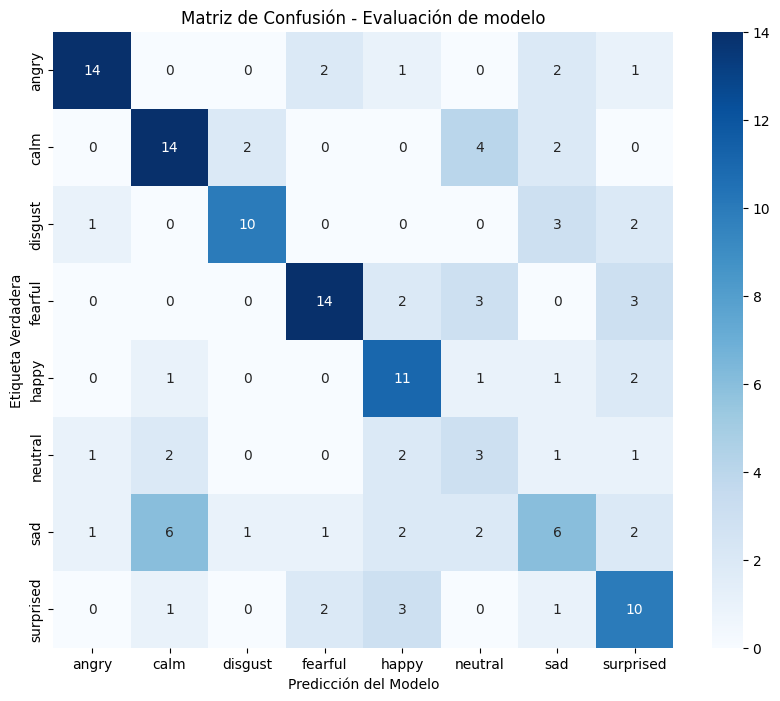

Matriz de confusion plana: 
 [[14  0  0  2  1  0  2  1]
 [ 0 14  2  0  0  4  2  0]
 [ 1  0 10  0  0  0  3  2]
 [ 0  0  0 14  2  3  0  3]
 [ 0  1  0  0 11  1  1  2]
 [ 1  2  0  0  2  3  1  1]
 [ 1  6  1  1  2  2  6  2]
 [ 0  1  0  2  3  0  1 10]]


In [13]:

# Define la ruta específica que vas a evaluar ahora
current_path = '/content/drive/MyDrive/saved_models_ResNet/best_model_for_mfcc'
# Prints
print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")
#Llamado a la funcion evaluadora
evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)



Evaluando modelo: best_model_for_spec


REPORTE DE CLASIFICACIÓN (CONJUNTO DE PRUEBA)
              precision    recall  f1-score   support

       angry       0.65      0.65      0.65        20
        calm       0.56      0.45      0.50        22
     disgust       0.67      0.75      0.71        16
     fearful       0.64      0.41      0.50        22
       happy       0.40      0.25      0.31        16
     neutral       0.17      0.10      0.12        10
         sad       0.32      0.43      0.37        21
   surprised       0.40      0.71      0.51        17

    accuracy                           0.49       144
   macro avg       0.48      0.47      0.46       144
weighted avg       0.50      0.49      0.48       144



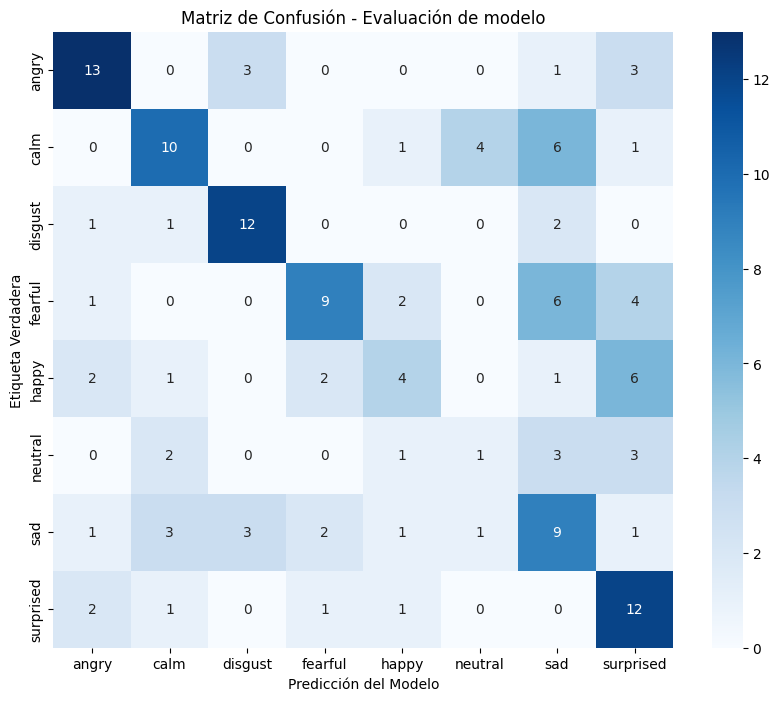

Matriz de confusion plana: 
 [[13  0  3  0  0  0  1  3]
 [ 0 10  0  0  1  4  6  1]
 [ 1  1 12  0  0  0  2  0]
 [ 1  0  0  9  2  0  6  4]
 [ 2  1  0  2  4  0  1  6]
 [ 0  2  0  0  1  1  3  3]
 [ 1  3  3  2  1  1  9  1]
 [ 2  1  0  1  1  0  0 12]]


In [15]:
current_path = '/content/drive/MyDrive/saved_models_ResNet/best_model_for_spec'

print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")

evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)


Evaluando modelo: best_model_for_mel_spec


REPORTE DE CLASIFICACIÓN (CONJUNTO DE PRUEBA)
              precision    recall  f1-score   support

       angry       0.82      0.70      0.76        20
        calm       0.70      0.64      0.67        22
     disgust       0.59      0.81      0.68        16
     fearful       0.52      0.59      0.55        22
       happy       0.47      0.56      0.51        16
     neutral       0.42      0.50      0.45        10
         sad       0.62      0.38      0.47        21
   surprised       0.75      0.71      0.73        17

    accuracy                           0.61       144
   macro avg       0.61      0.61      0.60       144
weighted avg       0.63      0.61      0.61       144



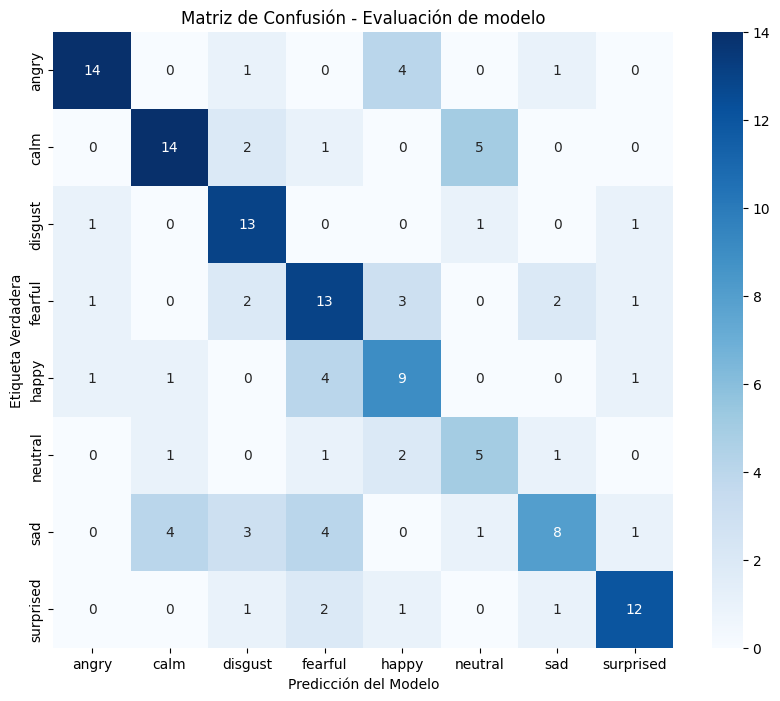

Matriz de confusion plana: 
 [[14  0  1  0  4  0  1  0]
 [ 0 14  2  1  0  5  0  0]
 [ 1  0 13  0  0  1  0  1]
 [ 1  0  2 13  3  0  2  1]
 [ 1  1  0  4  9  0  0  1]
 [ 0  1  0  1  2  5  1  0]
 [ 0  4  3  4  0  1  8  1]
 [ 0  0  1  2  1  0  1 12]]


In [11]:
current_path = '/content/drive/MyDrive/saved_models_ResNet/best_model_for_mel_spec'

print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")

evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)


Evaluando modelo: best_model_for_delta


REPORTE DE CLASIFICACIÓN (CONJUNTO DE PRUEBA)
              precision    recall  f1-score   support

       angry       0.73      0.55      0.63        20
        calm       0.75      0.41      0.53        22
     disgust       0.61      0.88      0.72        16
     fearful       0.52      0.59      0.55        22
       happy       0.53      0.56      0.55        16
     neutral       0.36      0.50      0.42        10
         sad       0.27      0.19      0.22        21
   surprised       0.35      0.47      0.40        17

    accuracy                           0.51       144
   macro avg       0.51      0.52      0.50       144
weighted avg       0.53      0.51      0.50       144



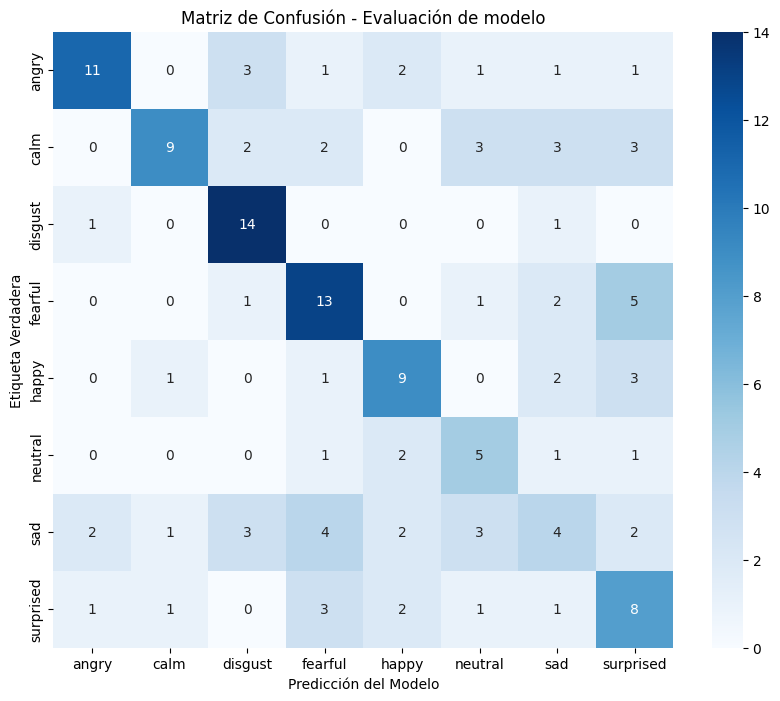

Matriz de confusion plana: 
 [[11  0  3  1  2  1  1  1]
 [ 0  9  2  2  0  3  3  3]
 [ 1  0 14  0  0  0  1  0]
 [ 0  0  1 13  0  1  2  5]
 [ 0  1  0  1  9  0  2  3]
 [ 0  0  0  1  2  5  1  1]
 [ 2  1  3  4  2  3  4  2]
 [ 1  1  0  3  2  1  1  8]]


In [17]:
current_path = '/content/drive/MyDrive/saved_models_ResNet/best_model_for_delta'

print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")

evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)


Evaluando modelo: best_model_for_delta2


REPORTE DE CLASIFICACIÓN (CONJUNTO DE PRUEBA)
              precision    recall  f1-score   support

       angry       0.61      0.55      0.58        20
        calm       0.55      0.55      0.55        22
     disgust       0.62      0.81      0.70        16
     fearful       0.43      0.45      0.44        22
       happy       0.35      0.38      0.36        16
     neutral       0.67      0.40      0.50        10
         sad       0.31      0.24      0.27        21
   surprised       0.24      0.29      0.26        17

    accuracy                           0.46       144
   macro avg       0.47      0.46      0.46       144
weighted avg       0.46      0.46      0.46       144



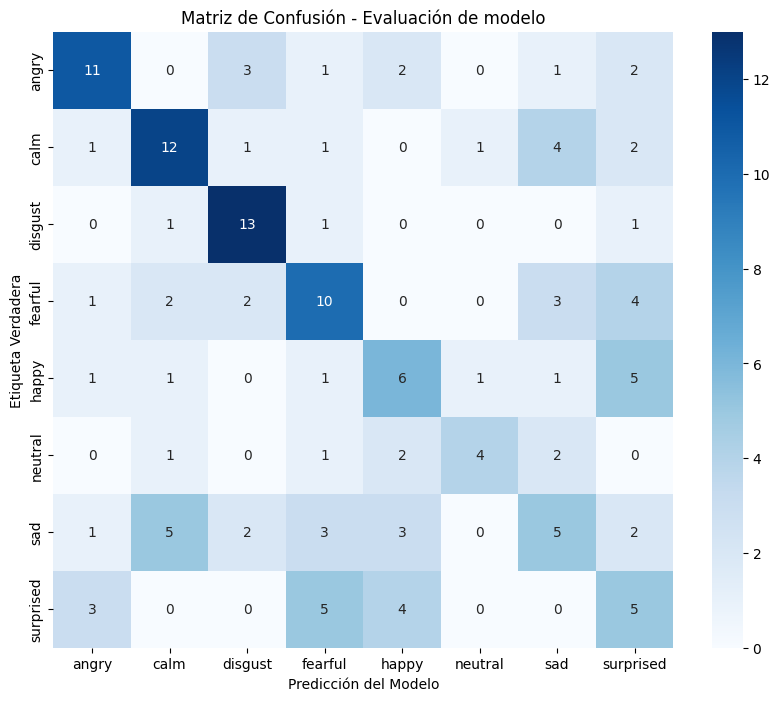

Matriz de confusion plana: 
 [[11  0  3  1  2  0  1  2]
 [ 1 12  1  1  0  1  4  2]
 [ 0  1 13  1  0  0  0  1]
 [ 1  2  2 10  0  0  3  4]
 [ 1  1  0  1  6  1  1  5]
 [ 0  1  0  1  2  4  2  0]
 [ 1  5  2  3  3  0  5  2]
 [ 3  0  0  5  4  0  0  5]]


In [19]:
current_path = '/content/drive/MyDrive/saved_models_ResNet/best_model_for_delta2'

print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")

evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)